# Home Credit Default Risk — Phase 1: Data Understanding

- File inventory (shape, size, key columns)
- Schema mapping and join keys
- Target variable analysis
- Data type profiling
- Missing value heatmap per file
- Relationship diagram across all 7 files

In [7]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display, HTML

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# ── Styling ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'  : '#FAFAFA',
    'axes.facecolor'    : '#FAFAFA',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.labelsize'    : 12,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'font.family'       : 'DejaVu Sans',
})
PALETTE = ['#534AB7', '#1D9E75', '#D85A30', '#BA7517', '#D4537E', '#378ADD', '#639922']

# ── Data directory ───────────────────────────────────────────────────────────
DATA_DIR = '../data'   # <-- update if your CSVs are in a subfolder, e.g. './data/'
print(f'Data directory: {os.path.abspath(DATA_DIR)}')

Data directory: c:\Users\User\Desktop\project\data


In [8]:
#define all files with metadata
FILES = {
    'application_train'     : 'application_train.csv',
    'application_test'      : 'application_test.csv',
    'bureau'                : 'bureau.csv',
    'bureau_balance'        : 'bureau_balance.csv',
    'previous_application'  : 'previous_application.csv',
    'POS_CASH_balance'      : 'POS_CASH_balance.csv',
    'installments_payments' : 'installments_payments.csv',
    'credit_card_balance'   : 'credit_card_balance.csv',
}

# load all files and collect basic stats
dfs = {}
inventory = []

for name, fname in FILES.items():
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        print(f'  [MISSING] {fname} — skipping')
        continue

    df = pd.read_csv(path)
    dfs[name] = df

    n_rows, n_cols = df.shape
    n_num  = df.select_dtypes(include='number').shape[1]
    n_cat  = df.select_dtypes(include='object').shape[1]
    null_pct = df.isnull().mean().mean() * 100
    size_mb  = df.memory_usage(deep=True).sum() / 1024**2
    has_target = 'TARGET' in df.columns

    inventory.append({
        'File'          : fname,
        'Rows'          : n_rows,
        'Columns'       : n_cols,
        'Numeric cols'  : n_num,
        'Categoric cols': n_cat,
        'Avg null %'    : round(null_pct, 2),
        'Size (MB)'     : round(size_mb, 1),
        'Has TARGET'    : '✓' if has_target else '—',
    })
    print(f'  ✓ Loaded  {fname:<40} shape={df.shape}')

print('\nDone.')

  ✓ Loaded  application_train.csv                    shape=(307511, 122)
  ✓ Loaded  application_test.csv                     shape=(48744, 121)
  ✓ Loaded  bureau.csv                               shape=(1716428, 17)
  ✓ Loaded  bureau_balance.csv                       shape=(27299925, 3)
  ✓ Loaded  previous_application.csv                 shape=(1670214, 37)
  ✓ Loaded  POS_CASH_balance.csv                     shape=(10001358, 8)
  ✓ Loaded  installments_payments.csv                shape=(13605401, 8)
  ✓ Loaded  credit_card_balance.csv                  shape=(3840312, 23)

Done.


In [9]:
# ── Pretty-print the inventory table ─────────────────────────────────────────
inv_df = pd.DataFrame(inventory)

display(
    inv_df.style
    .format({'Rows': '{:,}', 'Avg null %': '{:.1f}%', 'Size (MB)': '{:.1f}'})
    .set_caption('📋 Dataset Inventory — Home Credit Default Risk')
    .background_gradient(subset=['Avg null %'], cmap='Oranges')
    .background_gradient(subset=['Rows'], cmap='Blues')
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold'), ('text-align', 'left')]}])
)

,File,Rows,Columns,Numeric cols,Categoric cols,Avg null %,Size (MB),Has TARGET
0,application_train.csv,"307,511",122,106,16,24.4%,536.7,✓
1,application_test.csv,"48,744",121,105,16,23.8%,84.7,—
2,bureau.csv,"1,716,428",17,14,3,13.5%,512.1,—
3,bureau_balance.csv,"27,299,925",3,2,1,0.0%,1926.6,—
4,previous_application.csv,"1,670,214",37,21,16,18.0%,1900.6,—
5,POS_CASH_balance.csv,"10,001,358",8,7,1,0.1%,1137.3,—
6,installments_payments.csv,"13,605,401",8,8,0,0.0%,830.4,—
7,credit_card_balance.csv,"3,840,312",23,22,1,6.7%,875.7,—


# Join Key Validation

Before Phase 4 (merging), we verify:
- How many unique `SK_ID_CURR` exist in each file
- Coverage: what % of training applicants appear in each secondary file
- Rows per applicant (to understand aggregation load)

In [10]:
# ── Unique SK_ID_CURR coverage vs application_train ───────────────────────────
if 'application_train' in dfs:
    train_ids = set(dfs['application_train']['SK_ID_CURR'].unique())
    n_train   = len(train_ids)
    print(f'Total unique applicants in application_train: {n_train:,}\n')

    SECONDARY_FILES = [
        'bureau', 'previous_application',
        'POS_CASH_balance', 'installments_payments', 'credit_card_balance'
    ]

    key_stats = []
    for name in SECONDARY_FILES:
        if name not in dfs:
            continue
        df = dfs[name]
        unique_ids = df['SK_ID_CURR'].nunique()
        overlap    = len(set(df['SK_ID_CURR'].unique()) & train_ids)
        coverage   = overlap / n_train * 100
        rows_per   = len(df) / max(unique_ids, 1)

        key_stats.append({
            'File'                      : name,
            'Unique SK_ID_CURR'         : unique_ids,
            'Overlap with train'        : overlap,
            'Coverage of train (%)'     : round(coverage, 1),
            'Avg rows per applicant'    : round(rows_per, 1),
        })

    key_df = pd.DataFrame(key_stats)
    display(
        key_df.style
        .format({'Unique SK_ID_CURR': '{:,}', 'Overlap with train': '{:,}',
                 'Coverage of train (%)': '{:.1f}%', 'Avg rows per applicant': '{:.1f}'})
        .background_gradient(subset=['Coverage of train (%)'], cmap='Greens')
        .set_caption('🔑 Join Key Coverage Analysis')
    )

Total unique applicants in application_train: 307,511



,File,Unique SK_ID_CURR,Overlap with train,Coverage of train (%),Avg rows per applicant
0,bureau,"305,811","263,491",85.7%,5.6
1,previous_application,"338,857","291,057",94.6%,4.9
2,POS_CASH_balance,"337,252","289,444",94.1%,29.7
3,installments_payments,"339,587","291,643",94.8%,40.1
4,credit_card_balance,"103,558","86,905",28.3%,37.1


# Target Variable Analysis

This is a **binary classification** problem:
- `TARGET = 1` → client had payment difficulties (defaulted)
- `TARGET = 0` → all payments made on time

Understanding the class imbalance is critical for choosing loss functions and evaluation metrics.

TARGET distribution:
  Class 0 (No default)  :  282,686  (91.93%)
  Class 1 (Default)     :   24,825  (8.07%)
  Imbalance ratio       : 11.4:1


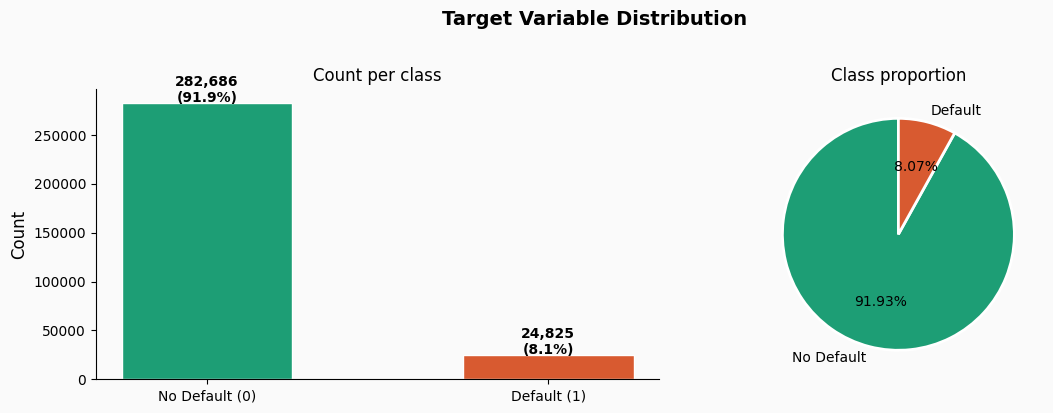


⚠️  Significant class imbalance (~8-9% defaults).
   → Will need: class_weight, SMOTE, or scale_pos_weight in modeling phase.


In [11]:
if 'application_train' in dfs:
    target = dfs['application_train']['TARGET']
    counts = target.value_counts()
    pcts   = target.value_counts(normalize=True) * 100

    print('TARGET distribution:')
    print(f'  Class 0 (No default)  : {counts[0]:>8,}  ({pcts[0]:.2f}%)')
    print(f'  Class 1 (Default)     : {counts[1]:>8,}  ({pcts[1]:.2f}%)')
    print(f'  Imbalance ratio       : {counts[0]/counts[1]:.1f}:1')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold', y=1.02)

    # Bar chart
    axes[0].bar(['No Default (0)', 'Default (1)'], counts.values,
                color=[PALETTE[1], PALETTE[2]], edgecolor='white', width=0.5)
    axes[0].set_title('Count per class')
    axes[0].set_ylabel('Count')
    for i, v in enumerate(counts.values):
        axes[0].text(i, v + 1000, f'{v:,}\n({pcts.values[i]:.1f}%)',
                     ha='center', fontsize=10, fontweight='bold')

    # Pie chart
    axes[1].pie(counts.values, labels=['No Default', 'Default'],
                colors=[PALETTE[1], PALETTE[2]], autopct='%1.2f%%',
                startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    axes[1].set_title('Class proportion')

    plt.tight_layout()
    plt.savefig('phase1_target_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\n⚠️  Significant class imbalance (~8-9% defaults).')
    print('   → Will need: class_weight, SMOTE, or scale_pos_weight in modeling phase.')

# Column-level Data Type Profiling

For each file we categorize columns into:
- **Numeric** (continuous / discrete)
- **Categorical** (low / high cardinality)
- **Boolean / binary**
- **ID columns** (to be excluded from modeling)

In [12]:
def profile_dtypes(df, name):
    """Return a summary of column types for a dataframe."""
    rows = []
    for col in df.columns:
        s         = df[col]
        dtype     = str(s.dtype)
        n_unique  = s.nunique()
        null_pct  = s.isnull().mean() * 100
        sample    = str(s.dropna().iloc[0]) if s.notna().any() else 'NaN'

        if col in ('SK_ID_CURR', 'SK_ID_BUREAU', 'SK_ID_PREV'):
            col_type = 'ID key'
        elif col == 'TARGET':
            col_type = 'Target'
        elif dtype == 'object':
            col_type = 'Categorical (high card)' if n_unique > 20 else 'Categorical (low card)'
        elif n_unique == 2:
            col_type = 'Binary'
        elif 'Days' in col or 'DAYS' in col:
            col_type = 'Numeric (days/time)'
        else:
            col_type = 'Numeric'

        rows.append({
            'Column'     : col,
            'Dtype'      : dtype,
            'Type'       : col_type,
            'Unique vals': n_unique,
            'Null %'     : round(null_pct, 1),
            'Sample val' : sample[:30],
        })
    return pd.DataFrame(rows)


# ── Show profile for application_train (main file) ────────────────────────────
if 'application_train' in dfs:
    prof = profile_dtypes(dfs['application_train'], 'application_train')

    print('application_train — column type summary:')
    print(prof['Type'].value_counts().to_string())
    print()

    # Show high-null columns (> 40%)
    high_null = prof[prof['Null %'] > 40].sort_values('Null %', ascending=False)
    print(f'Columns with >40% nulls: {len(high_null)}')
    if len(high_null):
        display(high_null[['Column', 'Type', 'Null %']].head(20))

application_train — column type summary:
Type
Numeric                79
Binary                 36
Numeric (days/time)     5
ID key                  1
Target                  1

Columns with >40% nulls: 49


,Column,Type,Null %
48,COMMONAREA_AVG,Numeric,69.90
76,COMMONAREA_MEDI,Numeric,69.90
62,COMMONAREA_MODE,Numeric,69.90
56,NONLIVINGAPARTMENTS_AVG,Numeric,69.40
84,NONLIVINGAPARTMENTS_MEDI,Numeric,69.40
70,NONLIVINGAPARTMENTS_MODE,Numeric,69.40
54,LIVINGAPARTMENTS_AVG,Numeric,68.40
86,FONDKAPREMONT_MODE,Numeric,68.40
82,LIVINGAPARTMENTS_MEDI,Numeric,68.40
68,LIVINGAPARTMENTS_MODE,Numeric,68.40


In [13]:
# ── Summary type counts across ALL files ─────────────────────────────────────
all_summaries = {}
for name, df in dfs.items():
    prof = profile_dtypes(df, name)
    type_counts = prof['Type'].value_counts()
    all_summaries[name] = type_counts

summary_df = pd.DataFrame(all_summaries).T.fillna(0).astype(int)
display(
    summary_df.style
    .background_gradient(cmap='Blues', axis=1)
    .set_caption('📊 Column Type Distribution Across All Files')
)

Type,Binary,ID key,Numeric,Numeric (days/time),Target
application_train,36,1,79,5,1
application_test,26,1,89,5,0
bureau,0,2,11,4,0
bureau_balance,0,1,2,0,0
previous_application,3,2,26,6,0
POS_CASH_balance,0,2,6,0,0
installments_payments,0,2,4,2,0
credit_card_balance,0,2,21,0,0


# Missing Value Heatmap — application_train

We visualize the % of missing values per column to identify:
- Columns to drop (>70% missing, little signal)
- Columns needing median/mode imputation
- Columns where missingness itself is a feature (create `_is_null` flag)

Columns with missing values: 67 / 122
  > 70% missing: 0
  40–70% missing: 49
  < 40% missing: 18


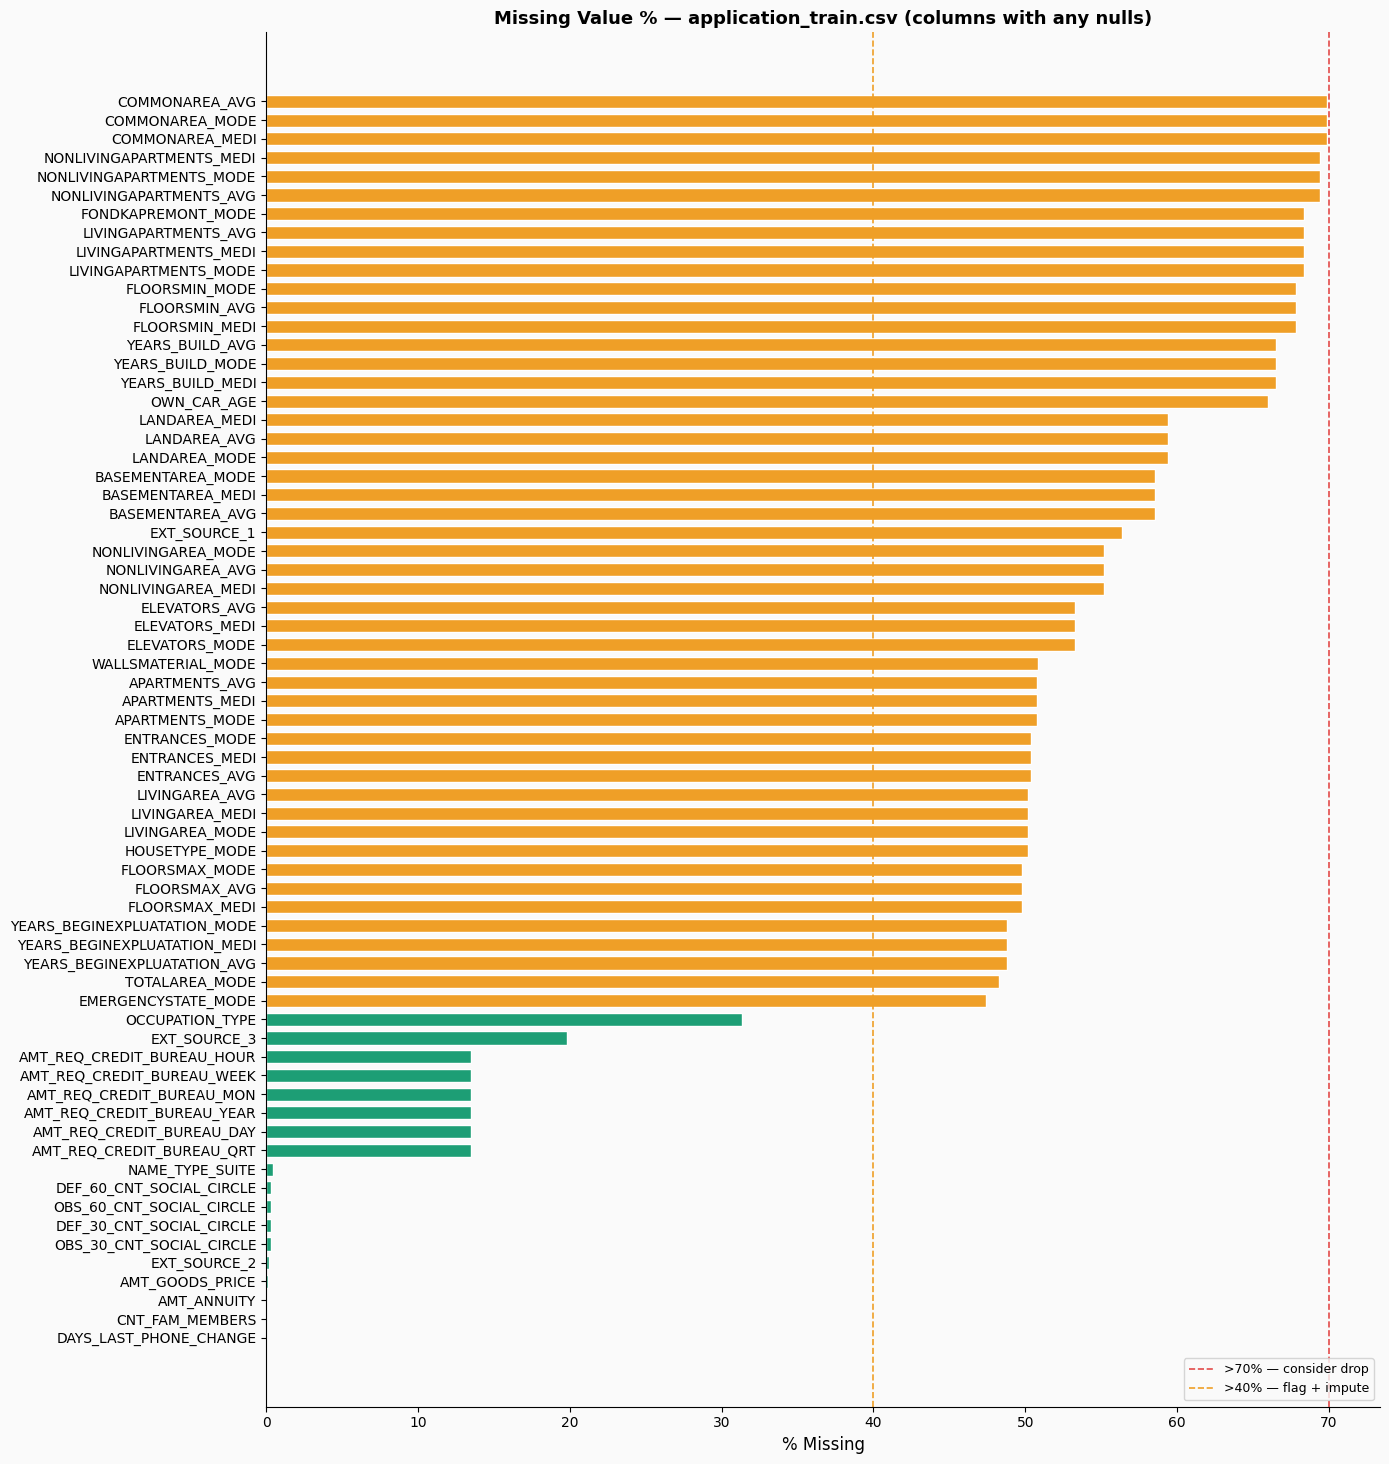

In [14]:
if 'application_train' in dfs:
    df = dfs['application_train']
    null_pcts = (df.isnull().mean() * 100).sort_values(ascending=False)
    null_pcts = null_pcts[null_pcts > 0]   # Only columns with at least 1 null

    print(f'Columns with missing values: {len(null_pcts)} / {df.shape[1]}')
    print(f'  > 70% missing: {(null_pcts > 70).sum()}')
    print(f'  40–70% missing: {((null_pcts > 40) & (null_pcts <= 70)).sum()}')
    print(f'  < 40% missing: {(null_pcts <= 40).sum()}')

    fig, ax = plt.subplots(figsize=(14, max(6, len(null_pcts) * 0.22)))
    colors = ['#E24B4A' if v > 70 else '#EF9F27' if v > 40 else '#1D9E75'
              for v in null_pcts.values]
    ax.barh(null_pcts.index, null_pcts.values, color=colors, edgecolor='white', height=0.7)
    ax.axvline(70, color='#E24B4A', linestyle='--', lw=1.2, label='>70% — consider drop')
    ax.axvline(40, color='#EF9F27', linestyle='--', lw=1.2, label='>40% — flag + impute')
    ax.set_xlabel('% Missing')
    ax.set_title('Missing Value % — application_train.csv (columns with any nulls)',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('phase1_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()

## Quick Peek at Each Secondary File

For each secondary file we check:
- How many rows per applicant
- Top categorical values
- Key numeric column ranges

In [15]:
SECONDARY = [
    'bureau', 'previous_application',
    'POS_CASH_balance', 'installments_payments', 'credit_card_balance'
]

for name in SECONDARY:
    if name not in dfs:
        continue
    df = dfs[name]
    print('=' * 70)
    print(f'  FILE: {name}')
    print('=' * 70)
    print(f'  Shape         : {df.shape}')
    print(f'  Columns       : {list(df.columns)}')
    print(f'  Nulls (avg %) : {df.isnull().mean().mean()*100:.1f}%')

    if 'SK_ID_CURR' in df.columns:
        rows_per = df.groupby('SK_ID_CURR').size()
        print(f'  Rows per SK_ID_CURR → mean={rows_per.mean():.1f}, '
              f'max={rows_per.max()}, min={rows_per.min()}')

    # Categorical column top values
    cat_cols = df.select_dtypes('object').columns.tolist()
    if cat_cols:
        print(f'  Categorical cols: {cat_cols}')
        for c in cat_cols[:3]:   # Show top 3 categoricals only
            print(f'    {c}: {dict(df[c].value_counts().head(4))}')

    print()

  FILE: bureau
  Shape         : (1716428, 17)
  Columns       : ['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']
  Nulls (avg %) : 13.5%
  Rows per SK_ID_CURR → mean=5.6, max=116, min=1
  Categorical cols: ['CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'CREDIT_TYPE']
    CREDIT_ACTIVE: {'Closed': np.int64(1079273), 'Active': np.int64(630607), 'Sold': np.int64(6527), 'Bad debt': np.int64(21)}
    CREDIT_CURRENCY: {'currency 1': np.int64(1715020), 'currency 2': np.int64(1224), 'currency 3': np.int64(174), 'currency 4': np.int64(10)}
    CREDIT_TYPE: {'Consumer credit': np.int64(1251615), 'Credit card': np.int64(402195), 'Car loan': np.int64(27690), 'Mortgage': np.int64(18391)}

  FILE: previous_application
  Sha

## bureau_balance — Nested Join

`bureau_balance.csv` links to `bureau.csv` via `SK_ID_BUREAU`, NOT directly to `application_train`.
To use it, you must:
1. Aggregate `bureau_balance` → `SK_ID_BUREAU` level
2. Merge into `bureau` → `SK_ID_BUREAU`
3. Then aggregate `bureau` → `SK_ID_CURR` level

This is a **2-level rollup**, which we'll handle in Phase 4.

In [16]:
if 'bureau_balance' in dfs and 'bureau' in dfs:
    bb = dfs['bureau_balance']
    b  = dfs['bureau']

    print('bureau_balance shape        :', bb.shape)
    print('bureau shape                :', b.shape)
    print('Unique SK_ID_BUREAU in bb   :', bb['SK_ID_BUREAU'].nunique())
    print('Unique SK_ID_BUREAU in b    :', b['SK_ID_BUREAU'].nunique())
    print()
    print('bureau_balance STATUS values:')
    print(bb['STATUS'].value_counts().to_string())
    print()
    print('→ STATUS meanings: 0=No debt, 1-5=Overdue months, C=Closed, X=Unknown')
    print('→ We will encode STATUS as ordinal (overdue severity) in Phase 3.')

bureau_balance shape        : (27299925, 3)
bureau shape                : (1716428, 17)
Unique SK_ID_BUREAU in bb   : 817395
Unique SK_ID_BUREAU in b    : 1716428

bureau_balance STATUS values:
STATUS
C    13646993
0     7499507
X     5810482
1      242347
5       62406
2       23419
3        8924
4        5847

→ STATUS meanings: 0=No debt, 1-5=Overdue months, C=Closed, X=Unknown
→ We will encode STATUS as ordinal (overdue severity) in Phase 3.


In [17]:
if 'application_train' in dfs:
    df   = dfs['application_train']
    prof = profile_dtypes(df, 'application_train')

    drop_candidates   = prof[prof['Null %'] > 70]['Column'].tolist()
    flag_candidates   = prof[(prof['Null %'] > 40) & (prof['Null %'] <= 70)]['Column'].tolist()
    impute_candidates = prof[(prof['Null %'] > 0)  & (prof['Null %'] <= 40)]['Column'].tolist()

    summary = {
        'Total files loaded'               : len(dfs),
        'Main file rows'                   : len(df),
        'Main file columns'                : df.shape[1],
        'Default rate (%)'                 : round(df['TARGET'].mean()*100, 2),
        'Imbalance ratio (0:1)'            : round((df['TARGET']==0).sum()/(df['TARGET']==1).sum(), 1),
        'Cols to DROP (>70% null)'         : len(drop_candidates),
        'Cols to FLAG + IMPUTE (40-70%)'   : len(flag_candidates),
        'Cols to IMPUTE (<40% null)'       : len(impute_candidates),
    }

    print('=' * 60)
    print('  PHASE 1 SUMMARY')
    print('=' * 60)
    for k, v in summary.items():
        print(f'  {k:<40} : {v}')

    print()
    print('DECISIONS FOR NEXT PHASES:')
    print('  Phase 2 (EDA)  → Focus on application_train first; univariate per column type.')
    print('  Phase 3 (Prep) → Drop >70% null cols; create _is_null flags for 40-70% null cols.')
    print('  Phase 4 (Feat) → Aggregate bureau, prev_app, installments, POS, CC at SK_ID_CURR level.')
    print('  Phase 5 (PCA)  → Apply on aggregated numeric blocks after merge.')
    print('  Phase 6 (Model)→ Use LightGBM with scale_pos_weight to handle class imbalance.')

    print()
    print('Candidate columns to DROP (>70% null):')
    print(drop_candidates)

print('\nPhase 1 complete. Proceed to Phase 2: Per-file EDA.')

  PHASE 1 SUMMARY
  Total files loaded                       : 8
  Main file rows                           : 307511
  Main file columns                        : 122
  Default rate (%)                         : 8.07
  Imbalance ratio (0:1)                    : 11.4
  Cols to DROP (>70% null)                 : 0
  Cols to FLAG + IMPUTE (40-70%)           : 49
  Cols to IMPUTE (<40% null)               : 15

DECISIONS FOR NEXT PHASES:
  Phase 2 (EDA)  → Focus on application_train first; univariate per column type.
  Phase 3 (Prep) → Drop >70% null cols; create _is_null flags for 40-70% null cols.
  Phase 4 (Feat) → Aggregate bureau, prev_app, installments, POS, CC at SK_ID_CURR level.
  Phase 5 (PCA)  → Apply on aggregated numeric blocks after merge.
  Phase 6 (Model)→ Use LightGBM with scale_pos_weight to handle class imbalance.

Candidate columns to DROP (>70% null):
[]

Phase 1 complete. Proceed to Phase 2: Per-file EDA.
